In [1]:
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

# Case 1: Single Plot

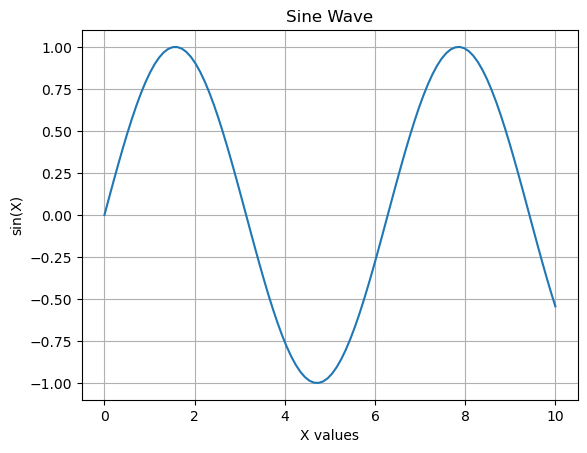

In [2]:
# Data
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Create figure and one axes
fig, ax = plt.subplots()

# Plot on that axes
ax.plot(x, y)

# Customize
ax.set_title("Sine Wave")
ax.set_xlabel("X values")
ax.set_ylabel("sin(X)")
ax.grid(True)

plt.show()

# Case 2: Multiple Subplots (2x2 Grid)

1. tight_layout() works at the Figure level, not Axes level.
2. It adjusts spacing between axes.
3. That’s why it's not: `ax.tight_layout()`
Because one axes cannot decide spacing relative to other axes.

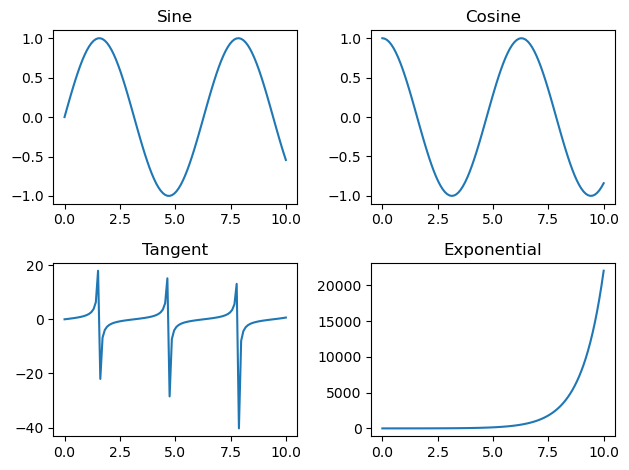

In [3]:
x = np.linspace(0, 10, 100)

# Create 2x2 grid
fig, ax = plt.subplots(2, 2)

# ax is now a 2D array of Axes objects
# ax[row][column]

ax[0,0].plot(x, np.sin(x))
ax[0,0].set_title("Sine")

ax[0,1].plot(x, np.cos(x))
ax[0,1].set_title("Cosine")

ax[1,0].plot(x, np.tan(x))
ax[1,0].set_title("Tangent")

ax[1,1].plot(x, np.exp(x))
ax[1,1].set_title("Exponential")

plt.tight_layout()
plt.show()

### 1️⃣ `plt.subplots()` → one Axes (not array)

```python
fig, ax = plt.subplots()
```
ax is a single object.

---

### 2️⃣ `plt.subplots(1, 2)` → 1D array

```python
fig, ax = plt.subplots(1, 2)
```
```
ax[0], ax[1]
```
It is NOT 2D.

---

### 3️⃣ `plt.subplots(2, 2)` → 2D array

```
ax[row, col]
```

---

Hierarchy:

```
Figure
 ├── Axes (subplot)
 │     ├── X-axis
 │     ├── Y-axis
 │     ├── Lines
 │     ├── Labels
 │     └── Title
```

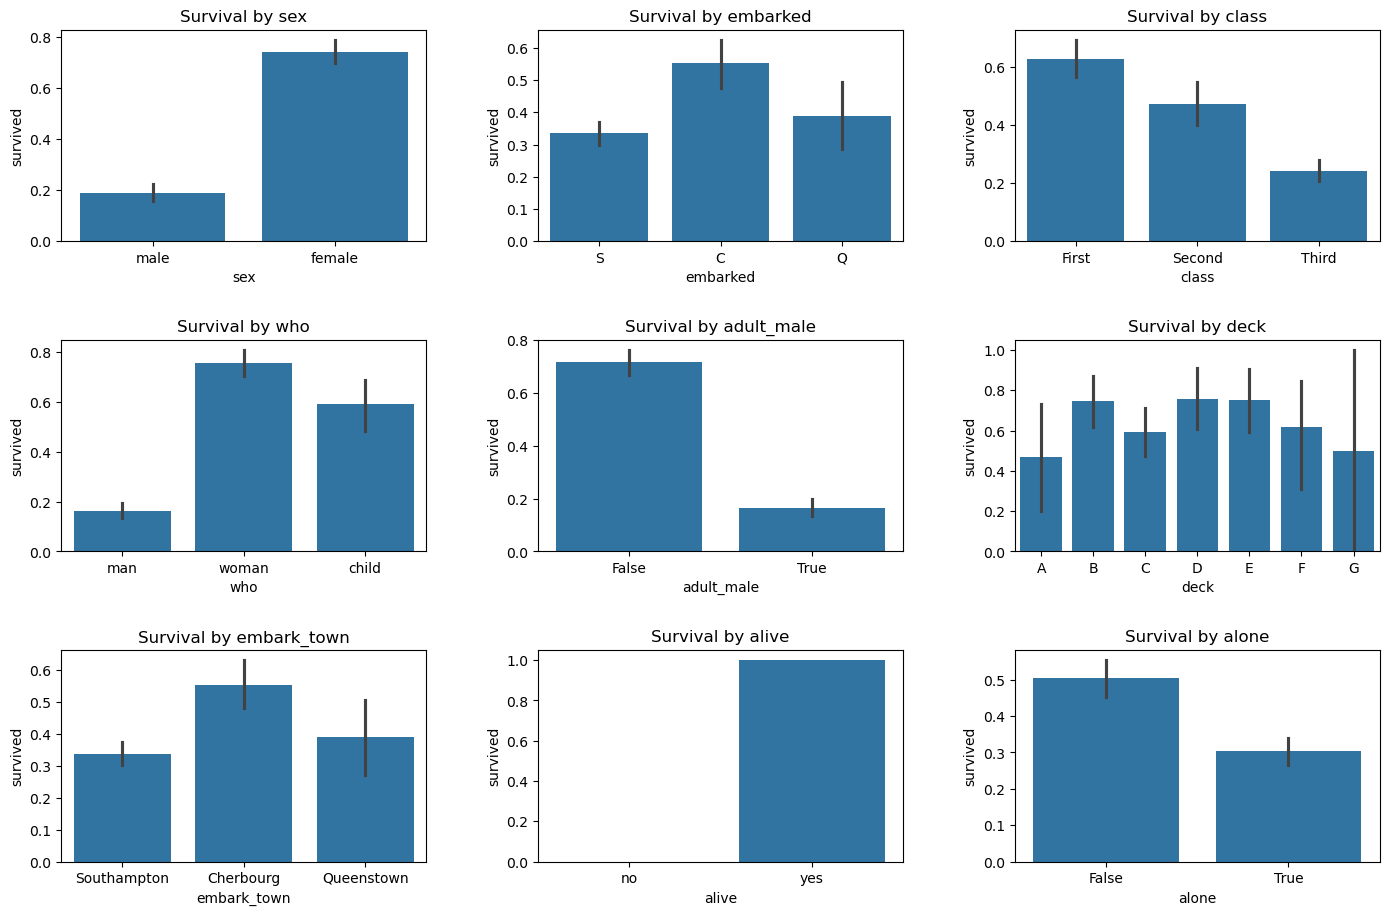

In [6]:

df = sns.load_dataset('titanic')
categorical_features = df.select_dtypes(include=["category", "object", "bool"]).columns.tolist()

fig, axs = plt.subplots(3, 3, figsize=(15, 10))
plt.tight_layout(pad=5.0)

axs = axs.flatten() # Because now i didn't have to do axs[0-2, 0-2] instead i can do axs[0-8]
for i, feature in enumerate(categorical_features):
    sns.barplot(x=feature, y="survived", data=df, ax=axs[i])
    axs[i].set_title(f'Survival by {feature}')

## 1) What each thing is

### `plt`

`plt` is the **pyplot interface** from Matplotlib.

Think of it as the **command center** for making figures:

* create figures
* create subplots
* change layout
* show the plot
* save the plot

So when you write:

```python
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
```

you are using `plt` to **create** a figure and its axes.

---

### `fig`

`fig` is the **entire figure container**.

It is the whole canvas that holds everything:

* all subplots
* titles
* spacing
* labels
* the full image area

So if you imagine a page with 9 small charts on it, `fig` is the **whole page**.

Common uses of `fig`:

* `fig.savefig(...)`
* `fig.suptitle(...)`
* adjusting overall figure properties

---

### `axs`

`axs` stands for **axes**.

An **axes** is one individual plotting area — one subplot.

In your code, since you created a 3 × 3 grid, `axs` initially contains **9 axes objects**, one for each small plot.

So:

* `fig` = whole canvas
* `axs` = the individual boxes where plots go

---

## 2) What `plt.subplots(3, 3, figsize=(15, 10))` does

```python
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
```

This means:

* make **1 figure**
* inside it, create a **3 by 3 grid** of subplots
* make the whole canvas size `15 × 10` inches

So the output is:

* `fig` → the whole figure
* `axs` → a 2D array of axes objects

At this point, `axs` is not a single axis. It is a grid like:

```python
axs[0, 0]  axs[0, 1]  axs[0, 2]
axs[1, 0]  axs[1, 1]  axs[1, 2]
axs[2, 0]  axs[2, 1]  axs[2, 2]
```

---

## 3) Why `plt.tight_layout(pad=5.0)` is used

```python
plt.tight_layout(pad=5.0)
```

This adjusts spacing so plots do not overlap.

It helps prevent:

* titles colliding
* axis labels overlapping
* plots looking cramped

`pad=5.0` means give extra spacing around elements.

A small note: often `tight_layout()` is called **after** adding the plots, because it works best once Matplotlib knows the labels and titles. But it can still work here depending on the final rendering.

---

## 4) Why `axs = axs.flatten()` is used

Since `axs` starts as a 2D grid, accessing each plot would require:

```python
axs[0, 0]
axs[0, 1]
axs[0, 2]
...
```

Flattening turns the 2D array into a 1D list-like structure:

```python
axs[0], axs[1], axs[2], ..., axs[8]
```

That makes looping much easier.

So this line:

```python
axs = axs.flatten()
```

changes your subplot access from:

* 2D indexing: `axs[row, col]`

to:

* 1D indexing: `axs[i]`


In [ ]:
#plot 1: 
x = np.array([0, 1, 2, 3]) 
y = np.array([3, 8, 1, 10]) 
plt.subplot(1, 2, 1) 
plt.plot(x,y) 
#plot 2: 
x = np.array([0, 1, 2, 3]) 
y = np.array([10, 20, 30, 40]) 
plt.subplot(1, 2, 2) 
plt.plot(x,y) 
plt.show() 